In [ ]:
# 1. INSTALACIÓN DE LIBRERÍAS
!pip -q install kagglehub
!pip install torchview

In [ ]:
# 2. IMPORTACIÓN DE LIBRERÍAS
import os
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import kagglehub

from torchview import draw_graph
from IPython.display import Image, display

In [ ]:
# ---------------------------
# 3. CONFIGURACIÓN DEL TOKEN
# ---------------------------
# Si de verdad quiere colocarlo directo, puede dejarse así.
# Aun así, sigue siendo más prudente cambiarlo después.

os.environ["KAGGLE_API_TOKEN"] = "PEGAR_AQUI_SU_TOKEN"

In [ ]:
# ---------------------------
# 4. DESCARGA DEL DATASET
# ---------------------------
dataset_path = kagglehub.dataset_download("rm1000/brain-tumor-mri-scans")

print("Ruta local del dataset:", dataset_path)
print("Contenido principal:", os.listdir(dataset_path))


Using Colab cache for faster access to the 'brain-tumor-mri-scans' dataset.
Ruta local del dataset: /kaggle/input/brain-tumor-mri-scans
Contenido principal: ['pituitary', 'healthy', 'meningioma', 'glioma']


In [ ]:
# ---------------------------
# 5. REPRODUCIBILIDAD Y DISPOSITIVO
# ---------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo disponible:", device)

Dispositivo disponible: cuda


In [ ]:
# ---------------------------
# 6. INSPECCIÓN DE LA ESTRUCTURA
# ---------------------------
print("\nEstructura del dataset:\n")
for root, dirs, files in os.walk(dataset_path):
    print("Carpeta:", root)
    print("Subcarpetas:", dirs)
    print("Cantidad de archivos:", len(files))
    print("-" * 70)


Estructura del dataset:

Carpeta: /kaggle/input/brain-tumor-mri-scans
Subcarpetas: ['pituitary', 'healthy', 'meningioma', 'glioma']
Cantidad de archivos: 0
----------------------------------------------------------------------
Carpeta: /kaggle/input/brain-tumor-mri-scans/pituitary
Subcarpetas: []
Cantidad de archivos: 1757
----------------------------------------------------------------------
Carpeta: /kaggle/input/brain-tumor-mri-scans/healthy
Subcarpetas: []
Cantidad de archivos: 2000
----------------------------------------------------------------------
Carpeta: /kaggle/input/brain-tumor-mri-scans/meningioma
Subcarpetas: []
Cantidad de archivos: 1645
----------------------------------------------------------------------
Carpeta: /kaggle/input/brain-tumor-mri-scans/glioma
Subcarpetas: []
Cantidad de archivos: 1621
----------------------------------------------------------------------


In [ ]:
# ---------------------------
# 7. DETECCIÓN AUTOMÁTICA DE ESTRUCTURA
# ---------------------------
possible_train = os.path.join(dataset_path, "Training")
possible_test = os.path.join(dataset_path, "Testing")

if os.path.isdir(possible_train) and os.path.isdir(possible_test):
    train_root = possible_train
    test_root = possible_test
    use_separate_test = True
    print("\nSe detectó estructura Training / Testing")
else:
    train_root = dataset_path
    test_root = None
    use_separate_test = False
    print("\nSe detectó estructura con clases directas en una sola carpeta")


Se detectó estructura con clases directas en una sola carpeta


In [ ]:
# ---------------------------
# 8. TRANSFORMACIONES
# ---------------------------
image_size = 128

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [ ]:
# ---------------------------
# 9. DATASET PERSONALIZADO
# ---------------------------
class CustomImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [ ]:
# ---------------------------
# 10. CARGA DE DATOS Y DIVISIÓN
# ---------------------------
full_train_folder = datasets.ImageFolder(root=train_root)

class_names = full_train_folder.classes
num_classes = len(class_names)

print("\nClases encontradas:", class_names)
print("Número de clases:", num_classes)

train_samples_all = full_train_folder.samples
train_targets_all = full_train_folder.targets

if use_separate_test:
    full_test_folder = datasets.ImageFolder(root=test_root)
    test_samples = full_test_folder.samples

    train_idx, val_idx = train_test_split(
        np.arange(len(train_samples_all)),
        test_size=0.2,
        stratify=train_targets_all,
        random_state=42
    )

    train_samples = [train_samples_all[i] for i in train_idx]
    val_samples = [train_samples_all[i] for i in val_idx]

else:
    all_samples = full_train_folder.samples
    all_targets = full_train_folder.targets

    train_idx, temp_idx = train_test_split(
        np.arange(len(all_samples)),
        test_size=0.3,
        stratify=all_targets,
        random_state=42
    )

    temp_targets = [all_targets[i] for i in temp_idx]

    val_subidx, test_subidx = train_test_split(
        np.arange(len(temp_idx)),
        test_size=0.5,
        stratify=temp_targets,
        random_state=42
    )

    train_samples = [all_samples[i] for i in train_idx]
    val_samples = [all_samples[temp_idx[i]] for i in val_subidx]
    test_samples = [all_samples[temp_idx[i]] for i in test_subidx]

print("\nCantidad de imágenes de entrenamiento:", len(train_samples))
print("Cantidad de imágenes de validación:", len(val_samples))
print("Cantidad de imágenes de prueba:", len(test_samples))



Clases encontradas: ['glioma', 'healthy', 'meningioma', 'pituitary']
Número de clases: 4

Cantidad de imágenes de entrenamiento: 4916
Cantidad de imágenes de validación: 1053
Cantidad de imágenes de prueba: 1054


In [ ]:
# ---------------------------
# 11. CONSTRUCCIÓN DE DATASETS Y DATALOADERS
# ---------------------------
train_dataset = CustomImageDataset(train_samples, transform=train_transform)
val_dataset = CustomImageDataset(val_samples, transform=eval_transform)
test_dataset = CustomImageDataset(test_samples, transform=eval_transform)

batch_size = 32

generator = torch.Generator()
generator.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("\nNúmero de lotes de entrenamiento:", len(train_loader))
print("Número de lotes de validación:", len(val_loader))
print("Número de lotes de prueba:", len(test_loader))


Número de lotes de entrenamiento: 154
Número de lotes de validación: 33
Número de lotes de prueba: 33


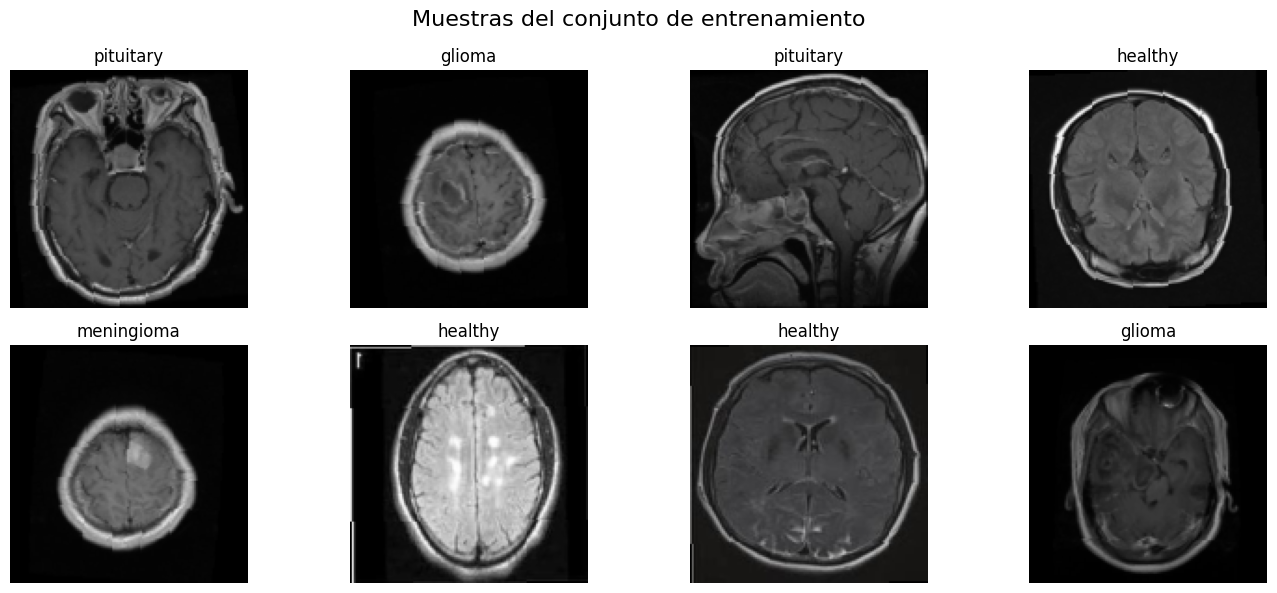

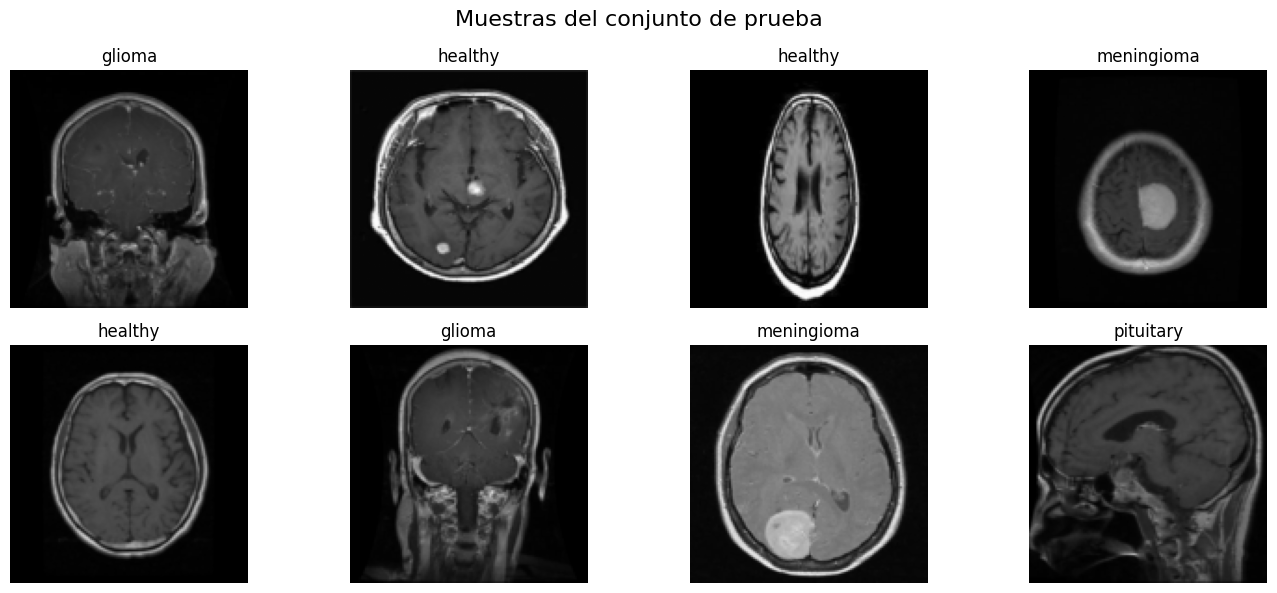

In [ ]:
# ---------------------------
# 12. VISUALIZAR IMÁGENES DEL CONJUNTO DE ENTRENAMIENTO
# ---------------------------
def show_images(data_loader, class_names, num_images=8, title="Muestras del conjunto"):
    images, labels = next(iter(data_loader))
    images = images[:num_images]
    labels = labels[:num_images]

    plt.figure(figsize=(14, 6))
    plt.suptitle(title, fontsize=16)

    for i in range(len(images)):
        img = images[i].numpy().transpose((1, 2, 0))
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_images(train_loader, class_names, num_images=8, title="Muestras del conjunto de entrenamiento")
show_images(test_loader, class_names, num_images=8, title="Muestras del conjunto de prueba")

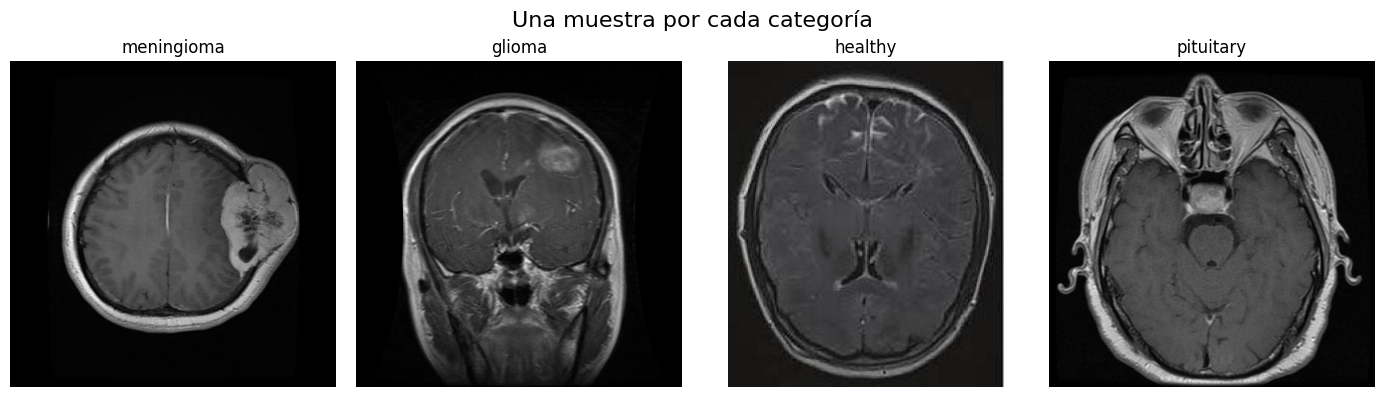

In [ ]:
# ---------------------------
# 13. VISUALIZAR UNA IMAGEN POR CADA CLASE
# ---------------------------
def show_one_example_per_class(samples, class_names, transform=None):
    shown = set()
    plt.figure(figsize=(14, 4))
    plt.suptitle("Una muestra por cada categoría", fontsize=16)

    plot_idx = 1
    for path, label in samples:
        if label not in shown:
            image = Image.open(path).convert("RGB")
            image_np = np.array(image)

            plt.subplot(1, len(class_names), plot_idx)
            plt.imshow(image_np)
            plt.title(class_names[label])
            plt.axis("off")

            shown.add(label)
            plot_idx += 1

        if len(shown) == len(class_names):
            break

    plt.tight_layout()
    plt.show()

show_one_example_per_class(train_samples, class_names)


## Arquitectura de la CNN
La arquitectura diseñada corresponde a una red neuronal convolucional (CNN) orientada a la clasificación de imágenes médicas. Esta se divide en dos componentes principales: un bloque de extracción de características y un bloque de clasificación.

En la primera etapa, se define un conjunto de capas convolucionales organizadas de forma secuencial (**self.features**), cuyo objetivo es identificar patrones relevantes dentro de las imágenes de entrada. Cada bloque convolucional está compuesto por una capa *Conv2d*, seguida de una función de activación *ReLU*, una normalización por lotes (*BatchNorm2d*) y una operación de reducción espacial mediante *MaxPool2d*.

En la segunda etapa (**self.classifier**), la información extraída es transformada a un vector unidimensional mediante una operación de *flatten*. Este vector es procesado por capas completamente conectadas (Linear), que permiten realizar la clasificación final. Se incluye una capa de *dropout* con el fin de reducir el sobreajuste, desactivando aleatoriamente un porcentaje de neuronas durante el entrenamiento.

In [ ]:
# ---------------------------
# 14. DEFINICIÓN DE LA CNN
# ---------------------------
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes):
        super(BrainTumorCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2, 2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BrainTumorCNN(num_classes=num_classes).to(device)
print("\nArquitectura del modelo:\n")
print(model)



Arquitectura del modelo:

BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): BatchNorm2d(256, eps=1e-05, mome

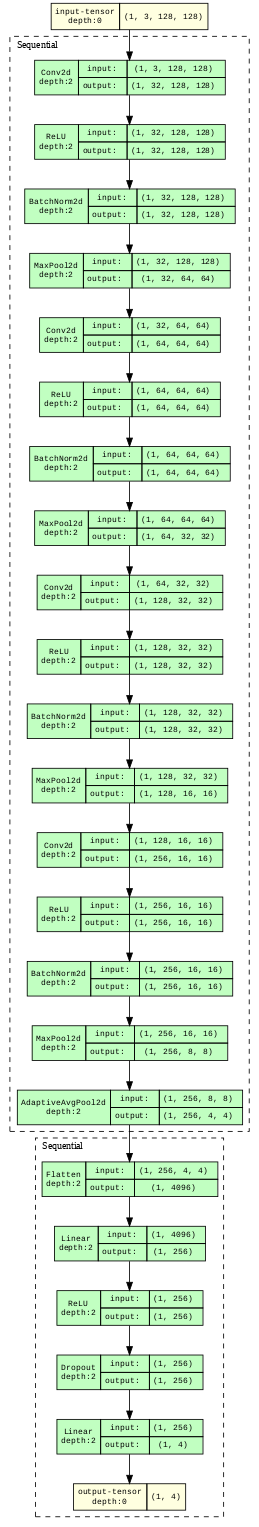

In [ ]:
graph = draw_graph(
    model,
    input_size=(1, 3, 128, 128),
    expand_nested=True
)

graph.visual_graph.render("cnn_architecture", format="png")
display(Image(filename="cnn_architecture.png"))

In [ ]:
# ---------------------------
# 15. FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR
# ---------------------------
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [ ]:
# ---------------------------
# 16. FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# ---------------------------
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds


In [ ]:
# ---------------------------
# 17. ENTRENAMIENTO DEL MODELO
# ---------------------------
num_epochs = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nÉpoca {epoch + 1}/{num_epochs}")
    print(f"Pérdida entrenamiento: {train_loss:.4f} | Exactitud entrenamiento: {train_acc:.4f}")
    print(f"Pérdida validación:    {val_loss:.4f} | Exactitud validación:  {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

end_time = time.time()

print("\nTiempo total de entrenamiento (minutos):", round((end_time - start_time) / 60, 2))
print("Mejor exactitud en validación:", round(best_val_acc, 4))



Época 1/15
Pérdida entrenamiento: 0.7350 | Exactitud entrenamiento: 0.7602
Pérdida validación:    0.5716 | Exactitud validación:  0.8291

Época 2/15
Pérdida entrenamiento: 0.5422 | Exactitud entrenamiento: 0.8574
Pérdida validación:    0.4428 | Exactitud validación:  0.9060

Época 3/15
Pérdida entrenamiento: 0.4795 | Exactitud entrenamiento: 0.8830
Pérdida validación:    0.4178 | Exactitud validación:  0.9155

Época 4/15
Pérdida entrenamiento: 0.4187 | Exactitud entrenamiento: 0.9184
Pérdida validación:    0.3787 | Exactitud validación:  0.9297

Época 5/15
Pérdida entrenamiento: 0.3818 | Exactitud entrenamiento: 0.9347
Pérdida validación:    0.3272 | Exactitud validación:  0.9582

Época 6/15
Pérdida entrenamiento: 0.3437 | Exactitud entrenamiento: 0.9514
Pérdida validación:    0.3277 | Exactitud validación:  0.9506

Época 7/15
Pérdida entrenamiento: 0.3291 | Exactitud entrenamiento: 0.9636
Pérdida validación:    0.3489 | Exactitud validación:  0.9468

Época 8/15
Pérdida entrenamiento:

In [ ]:
# ---------------------------
# 18. CARGAR MEJOR MODELO
# ---------------------------
model.load_state_dict(best_model_wts)

<All keys matched successfully>

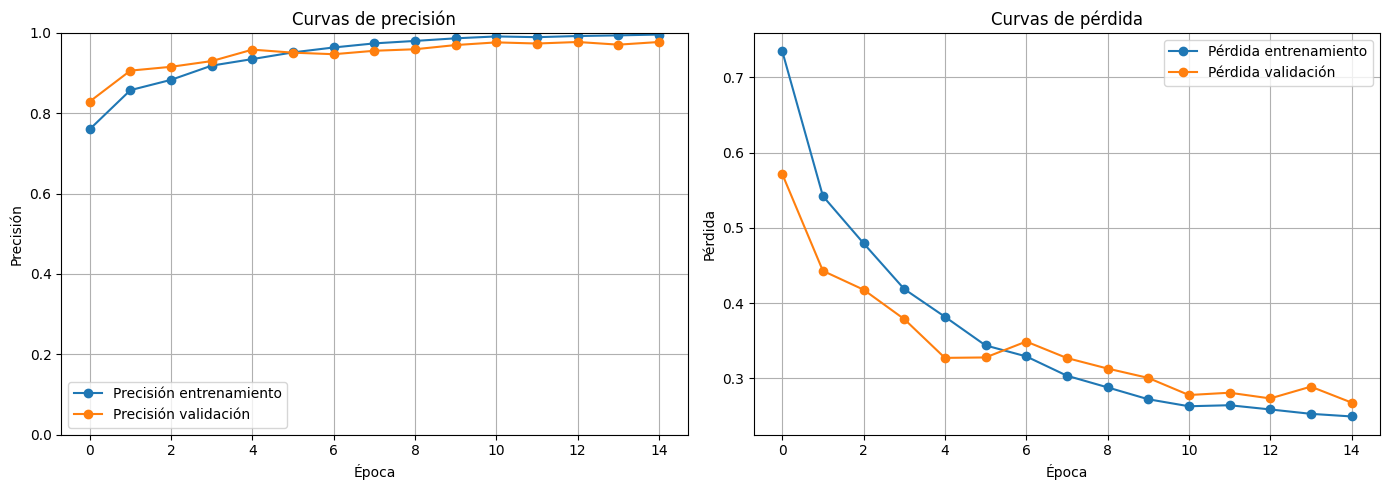

In [ ]:
# ---------------------------
# 19. CURVAS DE APRENDIZAJE
# ---------------------------
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["train_acc"], marker="o", label="Precisión entrenamiento")
    axes[0].plot(history["val_acc"], marker="o", label="Precisión validación")
    axes[0].set_title("Curvas de precisión")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Precisión")
    axes[0].set_ylim(0, 1)
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(history["train_loss"], marker="o", label="Pérdida entrenamiento")
    axes[1].plot(history["val_loss"], marker="o", label="Pérdida validación")
    axes[1].set_title("Curvas de pérdida")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Pérdida")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)


In [ ]:
# ---------------------------
# 20. EVALUACIÓN FINAL EN PRUEBA
# ---------------------------
test_loss, test_acc, y_true, y_pred = evaluate_model(model, test_loader, criterion, device)

print("\nResultados finales sobre el conjunto de prueba")
print("Pérdida en prueba:", round(test_loss, 4))
print("Exactitud en prueba:", round(test_acc, 4))


Resultados finales sobre el conjunto de prueba
Pérdida en prueba: 0.2921
Exactitud en prueba: 0.9696


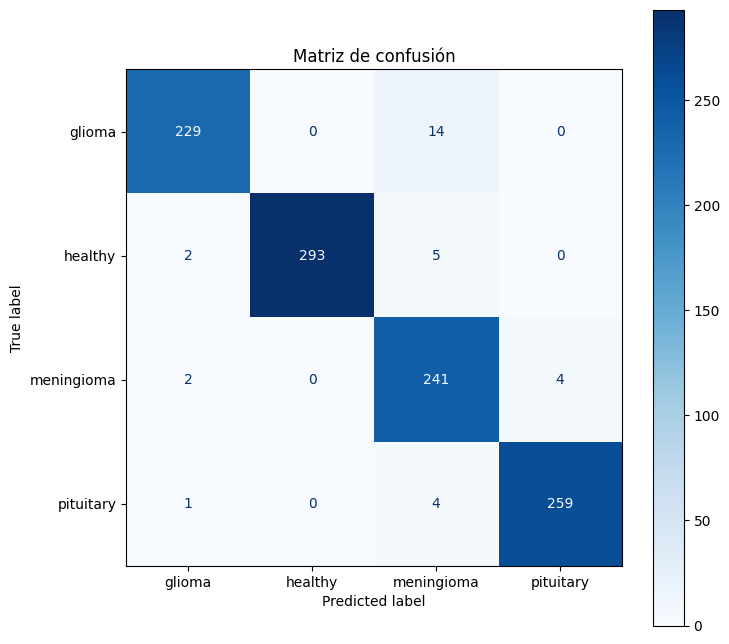

In [ ]:
# ---------------------------
# 21. MATRIZ DE CONFUSIÓN
# ---------------------------
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.show()


In [ ]:
# ---------------------------
# 22. REPORTE DE CLASIFICACIÓN
# ---------------------------
print("\nReporte de clasificación:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------
# 23. FUNCIÓN DE PREDICCIÓN SOBRE UNA IMAGEN
# ---------------------------
def predict_single_image(model, image_path, class_names, transform, device):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        _, pred = torch.max(output, 1)

    return class_names[pred.item()]


Reporte de clasificación:

              precision    recall  f1-score   support

      glioma       0.98      0.94      0.96       243
     healthy       1.00      0.98      0.99       300
  meningioma       0.91      0.98      0.94       247
   pituitary       0.98      0.98      0.98       264

    accuracy                           0.97      1054
   macro avg       0.97      0.97      0.97      1054
weighted avg       0.97      0.97      0.97      1054



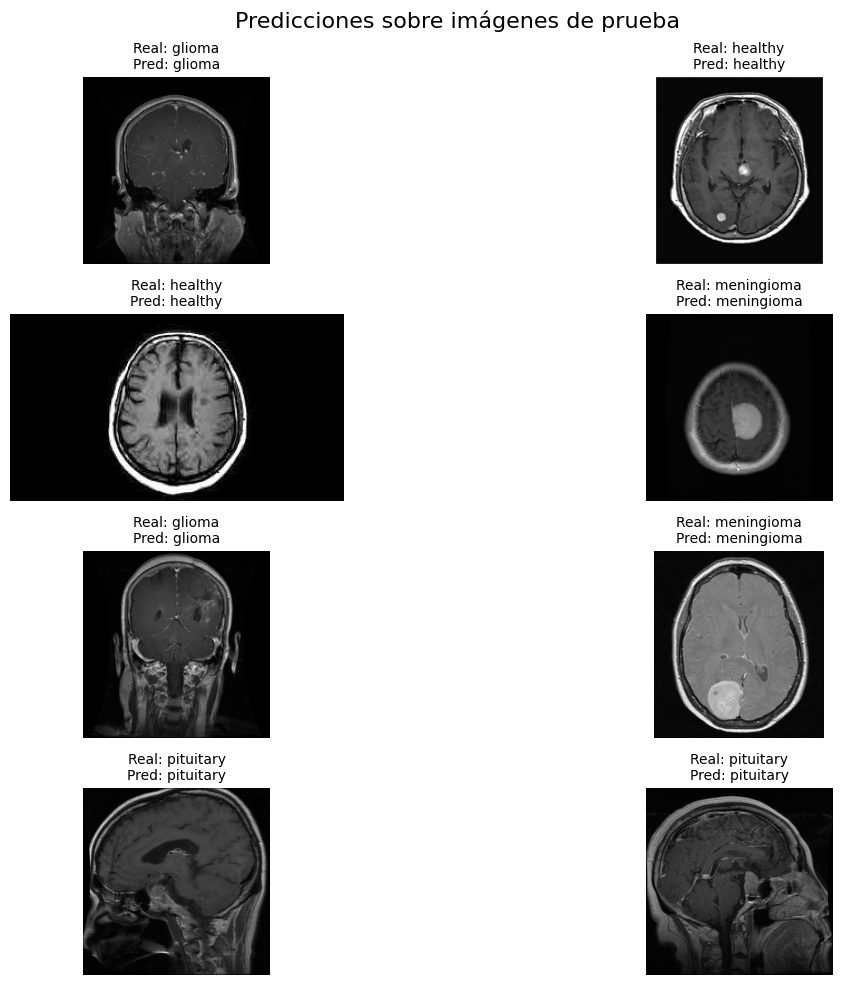

In [ ]:
# ---------------------------
# 24. MOSTRAR PREDICCIONES SOBRE IMÁGENES DE PRUEBA
# ---------------------------
def show_predictions_by_class(model, samples, class_names, transform, device, n_per_class=2):
    class_counter = {i: 0 for i in range(len(class_names))}
    max_images = len(class_names) * n_per_class
    shown = 0

    plt.figure(figsize=(14, 10))
    plt.suptitle("Predicciones sobre imágenes de prueba", fontsize=16)

    plot_idx = 1

    for path, true_label in samples:
        if class_counter[true_label] < n_per_class:
            pred_label = predict_single_image(model, path, class_names, transform, device)

            image = Image.open(path).convert("RGB")
            image_np = np.array(image)

            plt.subplot(len(class_names), n_per_class, plot_idx)
            plt.imshow(image_np)
            plt.title(f"Real: {class_names[true_label]}\nPred: {pred_label}", fontsize=10)
            plt.axis("off")

            class_counter[true_label] += 1
            shown += 1
            plot_idx += 1

        if shown >= max_images:
            break

    plt.tight_layout()
    plt.show()

show_predictions_by_class(model, test_samples, class_names, eval_transform, device, n_per_class=2)

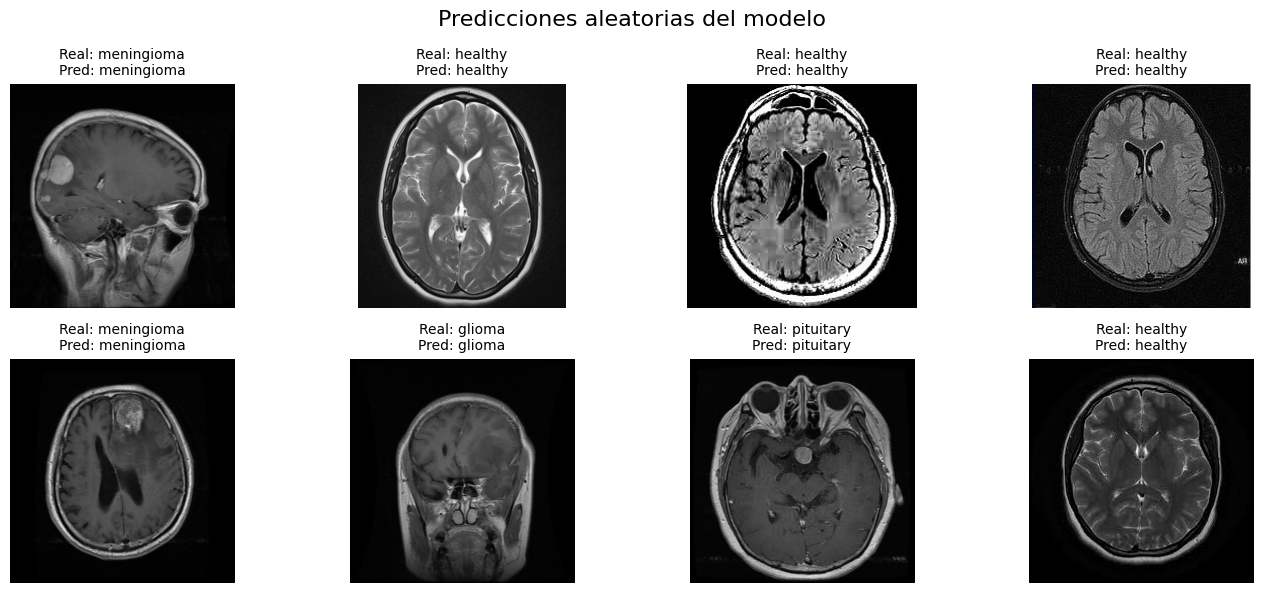

In [ ]:
# ---------------------------
# 25. PROBAR UNA MUESTRA ALEATORIA DE CADA CLASE
# ---------------------------
def show_random_predictions(model, samples, class_names, transform, device, num_images=8):
    selected_samples = random.sample(samples, min(num_images, len(samples)))

    plt.figure(figsize=(14, 6))
    plt.suptitle("Predicciones aleatorias del modelo", fontsize=16)

    for i, (path, true_label) in enumerate(selected_samples):
        pred_label = predict_single_image(model, path, class_names, transform, device)

        image = Image.open(path).convert("RGB")
        image_np = np.array(image)

        plt.subplot(2, 4, i + 1)
        plt.imshow(image_np)
        plt.title(f"Real: {class_names[true_label]}\nPred: {pred_label}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_predictions(model, test_samples, class_names, eval_transform, device, num_images=8)


In [ ]:
# ---------------------------
# 26. GUARDAR EL MODELO
# ---------------------------
model_path = "/content/brain_tumor_cnn_model.pth"
torch.save(model.state_dict(), model_path)
print("\nModelo guardado en:", model_path)


Modelo guardado en: /content/brain_tumor_cnn_model.pth


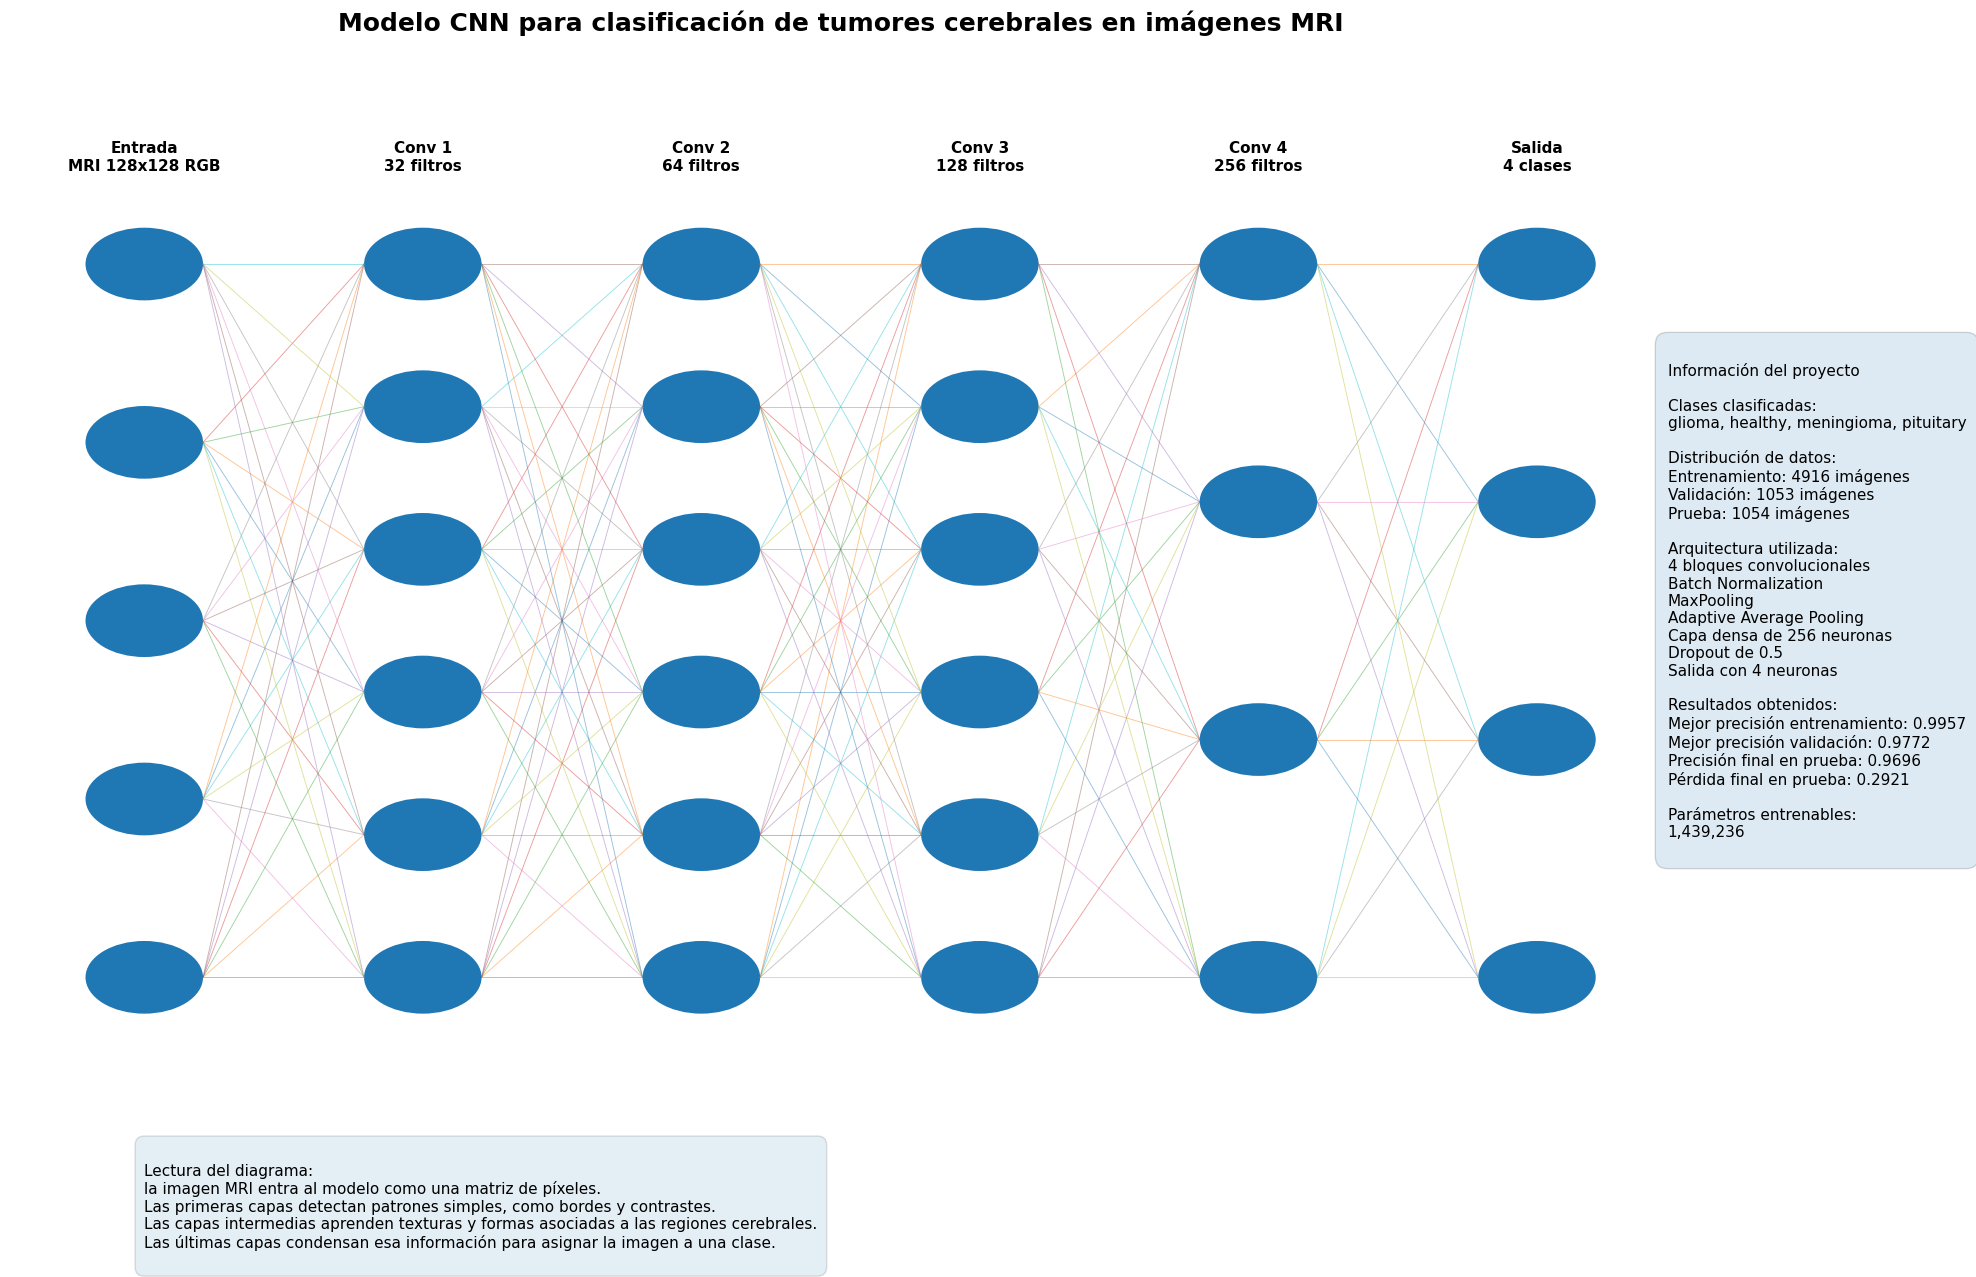

In [ ]:
# ---------------------------
# 27. VISUALIZACIÓN EXPLICATIVA DEL MODELO Y RESULTADOS DEL PROYECTO
# ---------------------------

import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn

def contar_parametros(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def visualizar_modelo_proyecto(
    model,
    class_names,
    train_samples,
    val_samples,
    test_samples,
    history,
    test_acc,
    test_loss
):
    model.eval()

    total_params = contar_parametros(model)
    mejor_val_acc = max(history["val_acc"])
    mejor_train_acc = max(history["train_acc"])
    ultima_val_loss = history["val_loss"][-1]

    layer_sizes = [5, 6, 6, 6, 4, len(class_names)]
    layer_names = [
        "Entrada\nMRI 128x128 RGB",
        "Conv 1\n32 filtros",
        "Conv 2\n64 filtros",
        "Conv 3\n128 filtros",
        "Conv 4\n256 filtros",
        "Salida\n" + str(len(class_names)) + " clases"
    ]

    fig, ax = plt.subplots(figsize=(17, 9))
    ax.axis("off")

    x_positions = np.linspace(0.08, 0.72, len(layer_sizes))
    node_positions = []

    for i, layer_size in enumerate(layer_sizes):
        x = x_positions[i]
        y_positions = np.linspace(0.25, 0.78, layer_size)

        current_layer = []

        for y in y_positions:
            circle = plt.Circle((x, y), 0.027, fill=True)
            ax.add_patch(circle)
            current_layer.append((x, y))

        node_positions.append(current_layer)

        ax.text(
            x, 0.86,
            layer_names[i],
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

    for i in range(len(node_positions) - 1):
        for x1, y1 in node_positions[i]:
            for x2, y2 in node_positions[i + 1]:
                ax.plot(
                    [x1 + 0.027, x2 - 0.027],
                    [y1, y2],
                    linewidth=0.65,
                    alpha=0.45
                )

    ax.text(
        0.40, 0.96,
        "Modelo CNN para clasificación de tumores cerebrales en imágenes MRI",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )

    texto_proyecto = f"""
Información del proyecto

Clases clasificadas:
{", ".join(class_names)}

Distribución de datos:
Entrenamiento: {len(train_samples)} imágenes
Validación: {len(val_samples)} imágenes
Prueba: {len(test_samples)} imágenes

Arquitectura utilizada:
4 bloques convolucionales
Batch Normalization
MaxPooling
Adaptive Average Pooling
Capa densa de 256 neuronas
Dropout de 0.5
Salida con {len(class_names)} neuronas

Resultados obtenidos:
Mejor precisión entrenamiento: {mejor_train_acc:.4f}
Mejor precisión validación: {mejor_val_acc:.4f}
Precisión final en prueba: {test_acc:.4f}
Pérdida final en prueba: {test_loss:.4f}

Parámetros entrenables:
{total_params:,}
"""

    ax.text(
        0.78, 0.53,
        texto_proyecto,
        ha="left",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.8", alpha=0.15)
    )

    explicacion = """
Lectura del diagrama:
la imagen MRI entra al modelo como una matriz de píxeles.
Las primeras capas detectan patrones simples, como bordes y contrastes.
Las capas intermedias aprenden texturas y formas asociadas a las regiones cerebrales.
Las últimas capas condensan esa información para asignar la imagen a una clase.
"""

    ax.text(
        0.08, 0.08,
        explicacion,
        ha="left",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.6", alpha=0.12)
    )

    plt.tight_layout()
    plt.show()

visualizar_modelo_proyecto(
    model=model,
    class_names=class_names,
    train_samples=train_samples,
    val_samples=val_samples,
    test_samples=test_samples,
    history=history,
    test_acc=test_acc,
    test_loss=test_loss
)